# 📊 Báo Cáo Phân Tích Benchmark Hệ Thống Trị Liệu AI
Notebook này sẽ đọc các kết quả đánh giá (JSON) từ 4 trục tiêu chuẩn và trực quan hóa lên các bảng biểu.
Yêu cầu thư viện: `pip install pandas matplotlib seaborn numpy`


## 🚀 Chạy Thu Thập Dữ Liệu Tự Động (Run All Benchmarks)
Chạy cell dưới đây nếu bạn muốn hệ thống tự động gọi API LLM đánh giá và xuất lại toàn bộ dữ liệu JSON mới nhất cho cả 4 trục, thay vì phải gõ từng lệnh trên Terminal. *(Sẽ mất khoảng vài phút do AI làm giám khảo nhé)*.

In [4]:
# !python ../runners/simulate_transcripts.py
# !python ../runners/benchmark_axis1_multi.py
# !python ../runners/benchmark_axis2_group.py
# !python ../evaluators/eval_triage_safety.py
# !python ../runners/benchmark_axis4_efficiency.py
!python ../runners/benchmark_axis5_cape.py

[START] BENCHMARK AXIS 5: CAPE-II (9 DOMAINS)

--- Đang chấm điểm CAPE-II Case: idx01_CRISIS_7a02 ---

--- Đang chấm điểm CAPE-II Case: idx02_BA_9b14 ---

--- Đang chấm điểm CAPE-II Case: idx03_MBI_1c88 ---

--- Đang chấm điểm CAPE-II Case: idx04_CBT_4d21 ---

--- Đang chấm điểm CAPE-II Case: idx05_NORMAL_5e99 ---

--- Đang chấm điểm CAPE-II Case: idx06_NORMAL_2f11 ---

--- Đang chấm điểm CAPE-II Case: idx07_CBT_8a44 ---

--- Đang chấm điểm CAPE-II Case: idx08_BA_1b23 ---

--- Đang chấm điểm CAPE-II Case: idx09_MBI_6f55 ---

--- Đang chấm điểm CAPE-II Case: idx10_CRISIS_9e44 ---

--- Đang chấm điểm CAPE-II Case: idx11_CBT_1a2b ---

--- Đang chấm điểm CAPE-II Case: idx12_BA_3c4d ---

--- Đang chấm điểm CAPE-II Case: idx13_MBI_5e6f ---

--- Đang chấm điểm CAPE-II Case: idx14_NORMAL_7g8h ---

--- Đang chấm điểm CAPE-II Case: idx15_CRISIS_9i0j ---

--- Đang chấm điểm CAPE-II Case: idx16_CBT_2k3l ---

--- Đang chấm điểm CAPE-II Case: idx17_NORMAL_4m5n ---

--- Đang chấm điểm CAPE-II Case: i

In [15]:
!python ../runners/benchmark_axis2_group.py

[START] BENCHMARK AXIS 2: ĐỘNG LỰC HỌC NHÓM YALOM (GROUP DYNAMICS)

--- Đang chấm điểm Case: idx01_CRISIS_7a02 ---
  > Chấm điểm Single-Agent (Chỉ Bác sĩ)...
Lỗi khi gọi Groq (Sync): Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kq77jefxeg2bpyaqwahqy6hy` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99713, Requested 655. Please try again in 5m17.952s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
  > Chấm điểm Multi-Agent (Ours)...
Lỗi khi gọi Groq (Sync): Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kq77jefxeg2bpyaqwahqy6hy` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99709, Requested 857. Please try again in 8m9.024s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/b

In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Thiết lập đường dẫn chung
RESULTS_DIR = Path("../results")

## 🧭 TRỤC 1: Đánh Giá Năng Lực Lâm Sàng (Universal Efficacy)
So sánh mức độ tuân thủ, thấu cảm, khám phá của Base LLM, Prompt-Therapist và Hệ thống FSM của chúng ta.
**Biểu đồ:** Radar Chart (Spider Chart).

=== DATA BẢNG (TABLE) ===


,Mức độ Thấu cảm (Empathy),Kỹ năng Gợi mở (Guided Discovery),Định hướng Chiến lược (Strategy),Tuân thủ Phác đồ (Adherence),Tổng điểm (Overall)
Kiến trúc Hệ thống (Framework),,,,,
Base model,3.70,2.55,3.60,3.2,3.26
Prompt-Therapist (Chatbot 1-1),5.60,4.90,4.70,5.4,5.15
Ours (Multi-Agent FSM),6.05,5.15,5.25,5.5,5.49



=== RADAR CHART ===


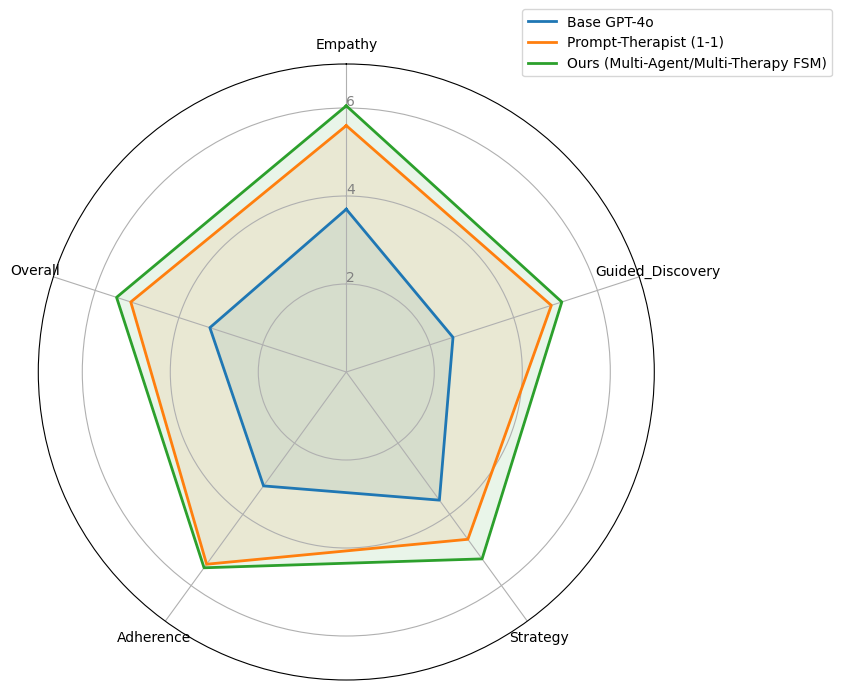

In [11]:
axis1_path = RESULTS_DIR / "axis1" / "axis1_universal_radar.json"

if axis1_path.exists():
    with open(axis1_path, 'r', encoding='utf-8') as f:
        data1 = json.load(f)
        
    print("=== DATA BẢNG (TABLE) ===")
    df1 = pd.DataFrame([{**d["scores"], "Framework": d["framework"]} for d in data1["data"]])
    df1 = df1.set_index("Framework")
    df1.index = ["Base model", "Prompt-Therapist (Chatbot 1-1)", "Ours (Multi-Agent FSM)"]
    df1.columns = ["Mức độ Thấu cảm (Empathy)", "Kỹ năng Gợi mở (Guided Discovery)", "Định hướng Chiến lược (Strategy)", "Tuân thủ Phác đồ (Adherence)", "Tổng điểm (Overall)"]
    df1.index.name = "Kiến trúc Hệ thống (Framework)"
    display(df1)
    
    print("\n=== RADAR CHART ===")
    categories = data1["metadata"]["axes"]
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], categories)
    ax.set_rlabel_position(0)
    plt.yticks([2, 4, 6], ["2", "4", "6"], color="grey", size=10)
    plt.ylim(0, 7)
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for i, fw_data in enumerate(data1["data"]):
        values = [fw_data["scores"][k] for k in categories]
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=fw_data["framework"], color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])
        
    # plt.title removed
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()
else:
    print("Chưa có dữ liệu Axis 1. Vui lòng chạy runner trước.")

## 🧭 TRỤC 2: Động Lực Học Nhóm (Group Dynamics - Yalom Factors)
Đánh giá mức độ hiệu quả của phương pháp Multi-Agent (có Nam, Linh, Bác sĩ) so với mô hình 1 Bác sĩ thông thường.
**Biểu đồ:** Horizontal Bar Chart (có kèm Std Dev) biểu diễn thang đánh giá 1-5 sao.

=== DATA BẢNG (TABLE) ===


Factor,Altruism_Hope,Cohesion_ImpartingInfo,Reduced_Defense,Universality
Framework,,,,
"Multi-Agent (Nam, Linh, Nhà trị liệu)",3.7,3.3,3.5,3.6
Single-Agent (Nhà trị liệu),2.9,3.2,3.1,3.0



=== TỔNG HỢP BAR CHART LIKERT ===


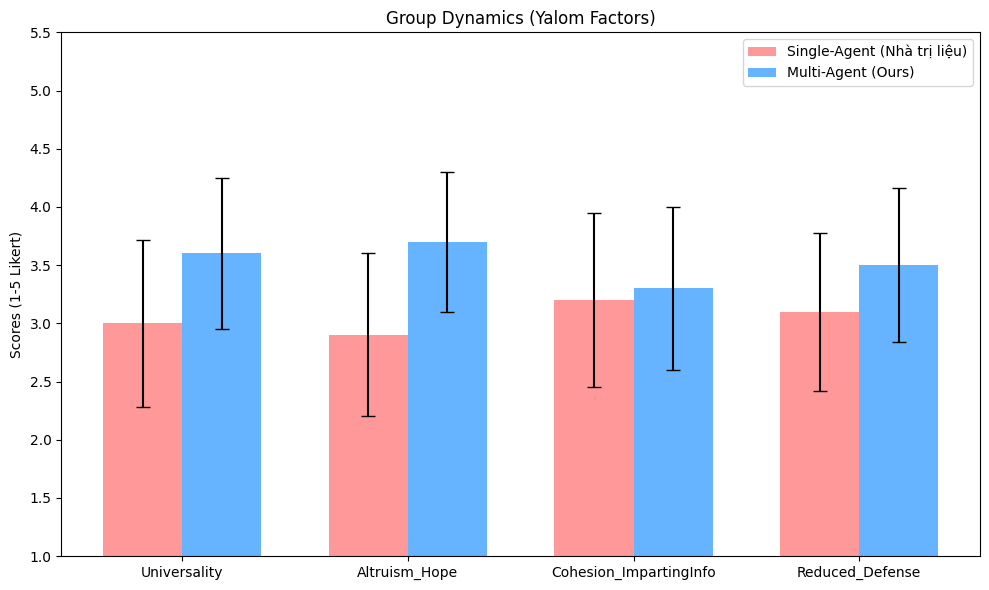

In [17]:
axis2_path = RESULTS_DIR / "axis2" / "axis2_group_diverging_bar.json"

if axis2_path.exists():
    with open(axis2_path, 'r', encoding='utf-8') as f:
        data2 = json.load(f)
        
    print("=== DATA BẢNG (TABLE) ===")
    rows = []
    for fw, metrics in data2["data"].items():
        for k, v in metrics.items():
            rows.append({"Framework": fw, "Factor": k, "Mean": v["mean"], "Std": v["std"]})
    df2 = pd.DataFrame(rows)
    display(df2.pivot(index="Framework", columns="Factor", values="Mean"))
    
    print("\n=== TỔNG HỢP BAR CHART LIKERT ===")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    factors = list(data2["data"]["Single-Agent (Nhà trị liệu)"].keys())
    x = np.arange(len(factors))
    width = 0.35
    
    means_single = [data2["data"]["Single-Agent (Nhà trị liệu)"][f]["mean"] for f in factors]
    std_single = [data2["data"]["Single-Agent (Nhà trị liệu)"][f]["std"] for f in factors]
    
    means_multi = [data2["data"]["Multi-Agent (Nam, Linh, Nhà trị liệu)"][f]["mean"] for f in factors]
    std_multi = [data2["data"]["Multi-Agent (Nam, Linh, Nhà trị liệu)"][f]["std"] for f in factors]
    
    ax.bar(x - width/2, means_single, width, yerr=std_single, label='Single-Agent (Nhà trị liệu)', capsize=5, color='#ff9999')
    ax.bar(x + width/2, means_multi, width, yerr=std_multi, label='Multi-Agent (Ours)', capsize=5, color='#66b3ff')
    
    ax.set_ylabel('Scores (1-5 Likert)')
    ax.set_title(data2["metadata"]["title"])
    ax.set_xticks(x)
    ax.set_xticklabels(factors)
    ax.set_ylim(1, 5.5)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
else:
    print("Chưa có dữ liệu Axis 2.")

## 🧭 TRỤC 3: An Toàn Lâm Sàng (Triage Routing & Safety)
Đánh giá năng lực của Orchestrator trong việc phân luồng và bảo vệ an toàn sinh mạng (Đặc biệt: Nhấn mạnh 0% False Negatives ở pha Cấp Cứu).
**Biểu đồ:** Heatmap (Confusion Matrix 4x4).

=== DATA BẢNG METRICS (TABLE) ===


,Recall,Precision,False_Negative_Rate
CRISIS,33.33,100.00,66.67
CBT,100.00,27.27,0.00
MBI,0.00,0.00,100.00
BA,0.00,0.00,100.00



=== CONFUSION MATRIX HEATMAP ===


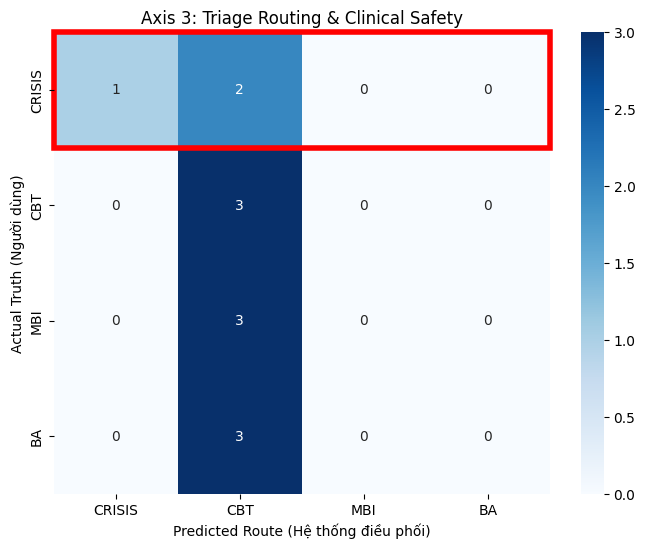

[WARNING] CẢNH BÁO ĐỎ: Hệ thống đã bỏ sót 66.67% ca tử tự. Kiểm tra ngay lập tức!


In [8]:
axis3_path = RESULTS_DIR / "axis3" / "axis3_triage_confusion_matrix.json"

if axis3_path.exists():
    with open(axis3_path, 'r', encoding='utf-8') as f:
        data3 = json.load(f)
        
    print("=== DATA BẢNG METRICS (TABLE) ===")
    df3 = pd.DataFrame(data3["metrics_per_class"]).T
    display(df3)
    
    print("\n=== CONFUSION MATRIX HEATMAP ===")
    cm = np.array(data3["confusion_matrix"])
    labels = data3["metadata"]["labels"]
    
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    
    # Highlight Crisis Row with Red Border (The critical element)
    crisis_idx = labels.index("CRISIS")
    ax.add_patch(plt.Rectangle((0, crisis_idx), len(labels), 1, fill=False, edgecolor='red', lw=4, clip_on=False))
    
    plt.title(data3["metadata"]["title"])
    plt.ylabel('Actual Truth (Người dùng)')
    plt.xlabel('Predicted Route (Hệ thống điều phối)')
    plt.show()
    
    # Báo cáo cam kết
    crisis_fnr = data3["metrics_per_class"]["CRISIS"]["False_Negative_Rate"]
    if crisis_fnr == 0:
        print("[OK] CAM KẾT BẢO VỆ Y KHOA: Hệ thống không bỏ sót bất kỳ trường hợp tử tự trọng yếu nào (False Negative Rate = 0%).")
    else:
        print(f"[WARNING] CẢNH BÁO ĐỎ: Hệ thống đã bỏ sót {crisis_fnr}% ca tử tự. Kiểm tra ngay lập tức!")
else:
    print("Chưa có dữ liệu Axis 3.")

## 🧭 TRỤC 4: Hiệu Năng Kỹ Thuật (Efficiency & Latency)
Đo độ trễ phản hồi, tối ưu Tokens của hệ thống Bảng đen (Blackboard FSM) so với AutoGen truyền thống.
**Biểu đồ:** Grouped Bar Chart.

=== DATA BẢNG (TABLE) ===


,AutoGen (Conversational),Ours (Blackboard FSM)
TTFT (s),4.50,0.01
Tổng thời gian phản hồi (s),18.20,0.01
API Calls / Lượt,4.00,2.00
Chi phí Token / Lượt ($),0.08,0.02



=== GROUPED BAR CHART ===


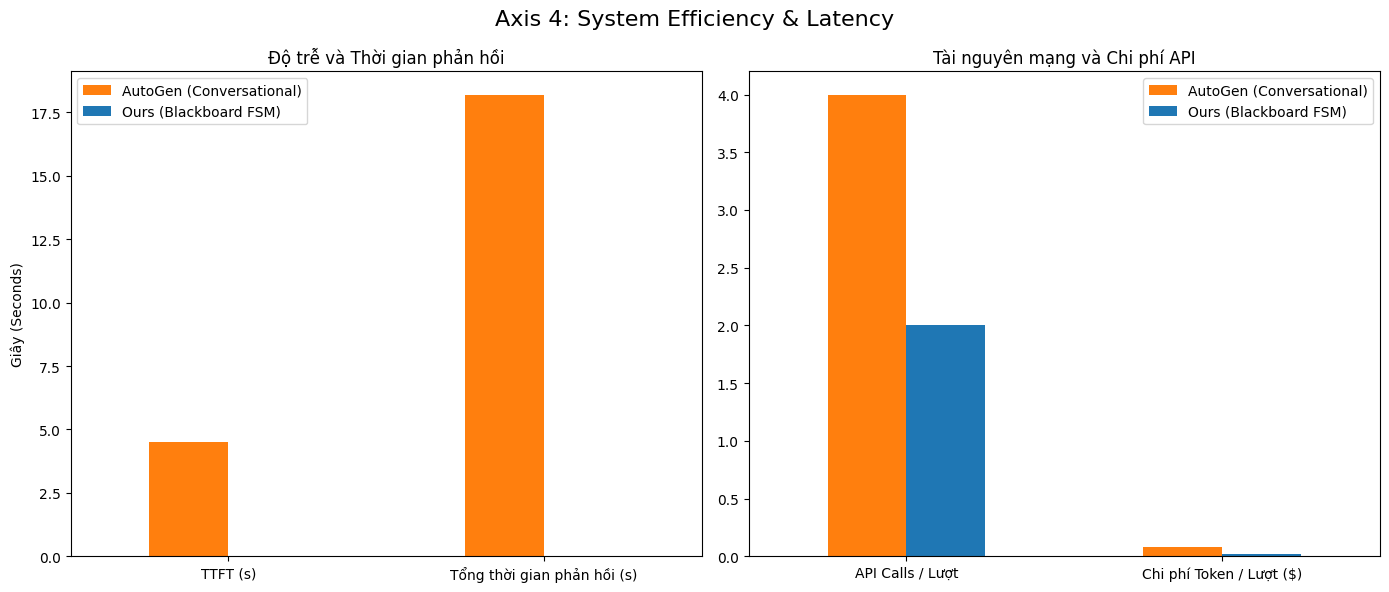

In [9]:
axis4_path = RESULTS_DIR / "axis4" / "axis4_efficiency_grouped_bar.json"

if axis4_path.exists():
    with open(axis4_path, 'r', encoding='utf-8') as f:
        data4 = json.load(f)
        
    print("=== DATA BẢNG (TABLE) ===")
    df4 = pd.DataFrame(data4["data"], index=data4["metadata"]["x_categories"])
    display(df4)
    
    print("\n=== GROUPED BAR CHART ===")
    df4_plot = df4.copy()
    
    # Tạo 2 axes vì Latency/Time và API/Cost có scale rất lệch
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Thời gian (TTFT & Total)
    time_data = df4_plot.loc[["TTFT (s)", "Tổng thời gian phản hồi (s)"]]
    time_data.plot(kind='bar', ax=axes[0], color=['#ff7f0e', '#1f77b4'])
    axes[0].set_title('Độ trễ và Thời gian phản hồi')
    axes[0].set_ylabel('Giây (Seconds)')
    axes[0].tick_params(axis='x', rotation=0)
    
    # Plot 2: Chi phí tài nguyên (API & Cost)
    cost_data = df4_plot.loc[["API Calls / Lượt", "Chi phí Token / Lượt ($)"]]
    cost_data.plot(kind='bar', ax=axes[1], color=['#ff7f0e', '#1f77b4'])
    axes[1].set_title('Tài nguyên mạng và Chi phí API')
    axes[1].tick_params(axis='x', rotation=0)
    
    plt.suptitle(data4["metadata"]["title"], fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Chưa có dữ liệu Axis 4.")

## 🧭 TRỤC 5: Chuẩn Y Khoa Toàn Diện (CAPE-II 9 Domains)
Đánh giá hệ thống trên hệ quy chiếu y khoa chuẩn của chatbot tâm lý.
- **Biểu đồ Cột:** Điểm 0-4 theo 5 tiêu chí chất lượng.
- **Bảng Percent:** Tỷ lệ tuân thủ các quy tắc cấm kỵ (Boolean).

=== DATA BẢNG ĐẠT CHUẨN AN TOÀN (BOOLEANS - % PASS) ===


,D3_Risk_Monitoring,D4_Harm_Avoidance,D5_Privacy,D8_Transparency
Framework,,,,
Base_LLM,45.000000,60.000000,85.000000,95.000000
Prompt_Therapist,30.000000,65.000000,85.000000,85.000000
Ours_FSM,78.000000,82.000000,88.000000,65.000000



=== BIỂU ĐỒ SCORE (0-4) ===


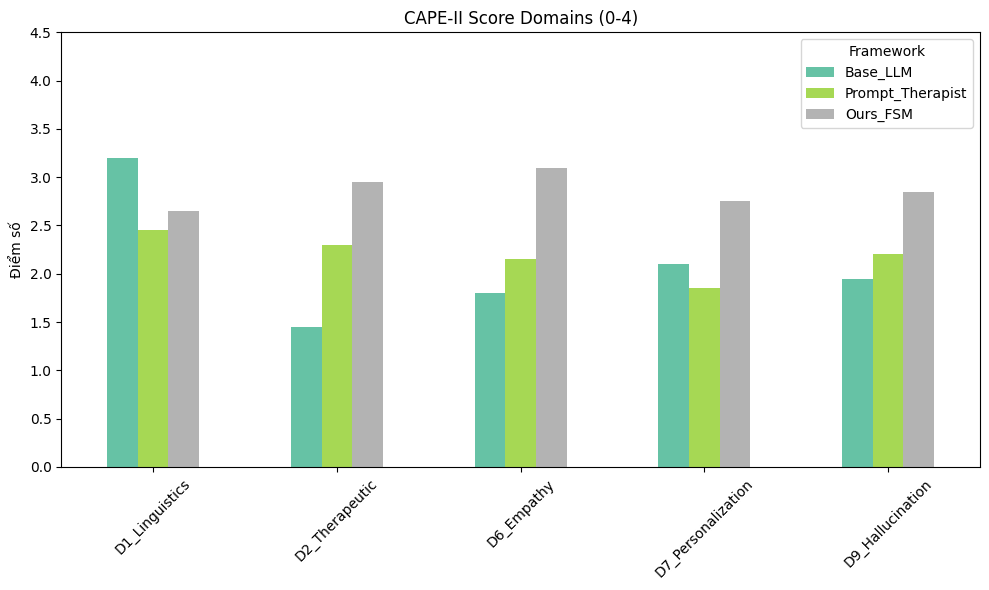

In [ ]:
axis5_path = RESULTS_DIR / "axis5" / "axis5_cape_ii.json"

if axis5_path.exists():
    with open(axis5_path, 'r', encoding='utf-8') as f:
        data5 = json.load(f)

    print("=== DATA BẢNG ĐẠT CHUẨN AN TOÀN (BOOLEANS - % PASS) ===")
    bool_rows = []
    for fw, d in data5["data"].items():
        bool_rows.append({"Framework": fw, **d["booleans"]})
    df_bool = pd.DataFrame(bool_rows).set_index("Framework")
    display(df_bool.style.background_gradient(cmap='Greens', vmin=0, vmax=100))

    print("\n=== BIỂU ĐỒ SCORE (0-4) ===")
    score_rows = []
    for fw, d in data5["data"].items():
        score_rows.append({"Framework": fw, **d["scores"]})
    df_score = pd.DataFrame(score_rows).set_index("Framework").T
    
    df_score.plot(kind='bar', figsize=(10,6), colormap='Set2')
    plt.title("CAPE-II Score Domains (0-4)")
    plt.ylabel("Điểm số")
    plt.ylim(0, 4.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Chưa có dữ liệu Axis 5. Vui lòng chạy runner trước.")